In [1]:
from qubic.lib.Qhdf5 import HDF5Dict
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from qubic.lib.QskySim import get_angular_profile
import matplotlib.patches as mpatches

from pysimulators.interfaces.healpy import HealpixConvolutionGaussianOperator

%matplotlib inline

# Import data

In [2]:
hdf5 = HDF5Dict()
data = hdf5.load_dict("parametric_d1_UWB_test_d1_prior/Dict/test_None.h5")

In [3]:
data.keys()

dict_keys(['convergence', 'fsky', 'A', 'Atrue', 'G', 'TOD_external', 'TOD_qubic', 'all_gain', 'beta', 'beta_true', 'center', 'comps_name', 'coverage', 'fwhm_in', 'fwhm_out', 'fwhm_rec', 'g', 'gi', 'index_beta', 'maps', 'maps_in', 'maps_in_convolved', 'maps_noise', 'nus_in', 'nus_out', 'parameters', 'qubic_dict', 'seenpix', 'seenpix_beta'])

In [4]:
fwhm_in = data["fwhm_in"]
fwhm_out = data["fwhm_out"]
fwhm_rec = data["fwhm_rec"]

comp_maps_input = data["maps_in_convolved"]
comp_maps_rec = data["maps"]

# for i in range(2):
#     C = HealpixConvolutionGaussianOperator(0.02)
#     comp_maps_input[i] = C(comp_maps_input[i])
#     comp_maps_rec[i] = C(comp_maps_rec[i])
comp_maps_res = comp_maps_input - comp_maps_rec
center = data["center"]
seenpix = data["seenpix"]
convergence = data["convergence"]
print(comp_maps_input.shape)


(2, 196608, 3)


# Plot Convergence

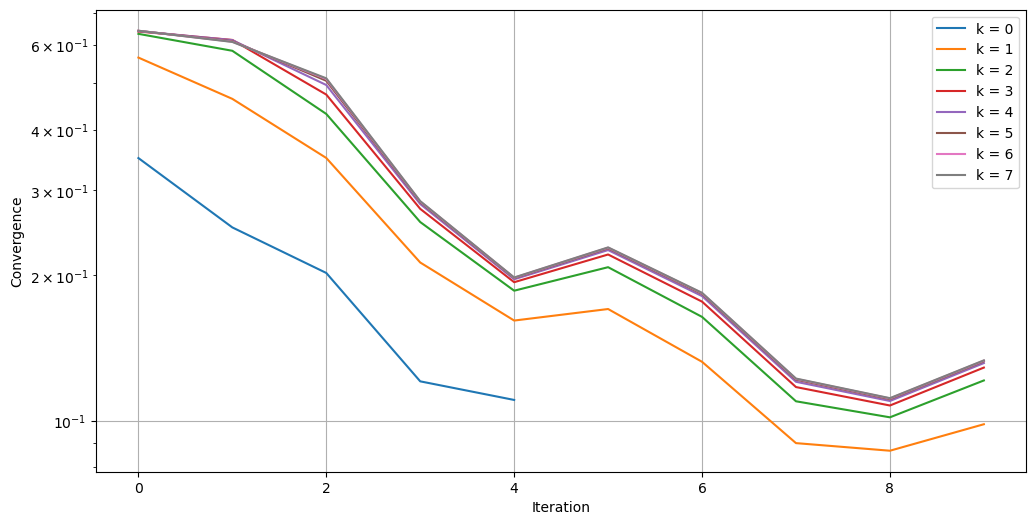

In [5]:
plt.figure(figsize=(12, 6))
for i in range(len(convergence)):
    plt.plot(convergence[i], label=f"k = {i}")

plt.xlabel("Iteration")
plt.ylabel("Convergence")
plt.legend()
plt.grid()
plt.yscale("log")
plt.legend()

In [6]:
# plt.plot(convergence[-1])
# plt.xlabel("Iteration")
# plt.ylabel("Convergence")
# plt.title("PCG Convergence")
# plt.yscale("log")
# plt.grid()
# plt.show()

# Plot maps

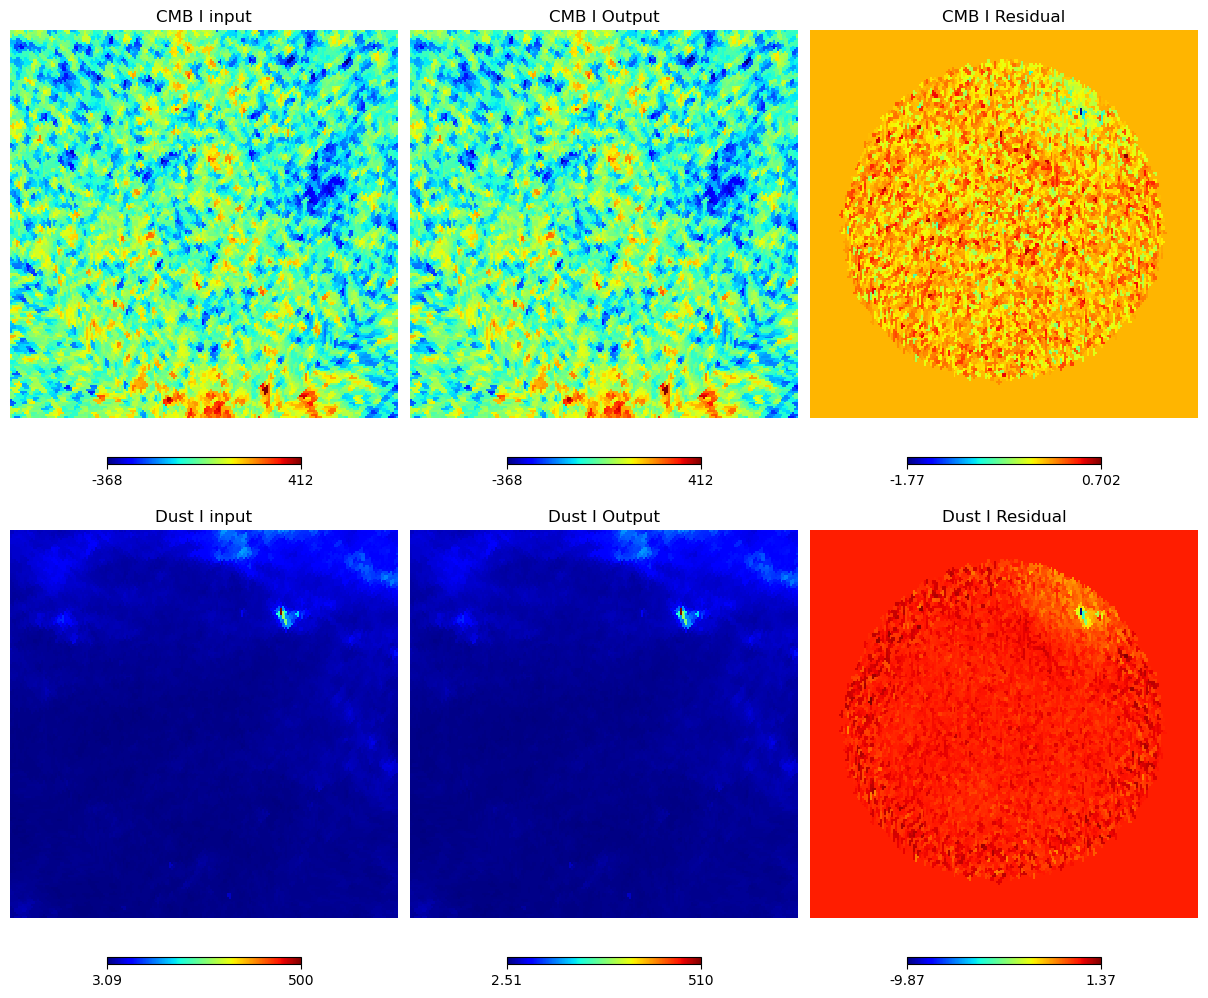

In [7]:
plt.figure(figsize=(12, 10))
name_comp = ["CMB", "Dust", "Synchrotron"]
STOKES = ["I", "Q", "U"]

# comp_maps_input[:, ~seenpix, :] = hp.UNSEEN
# comp_maps_rec[:, ~seenpix, :] = hp.UNSEEN
# comp_maps_res[:, ~seenpix, :] = hp.UNSEEN


istk = 0
n = comp_maps_input.shape[0]
sigma_input = np.std(comp_maps_input[:, seenpix, istk], axis=0)
sigma_rec = np.std(comp_maps_rec[:, seenpix, istk], axis=0)
sigma_res = np.std(comp_maps_rec[:, seenpix, istk] - comp_maps_input[:, seenpix, istk], axis=0)

reso = 15

k = 0

for icomp in range(n):
    C = HealpixConvolutionGaussianOperator(0)#fwhm_rec[icomp])
    hp.gnomview((C(comp_maps_input[icomp])[ :, istk]), rot=center,

                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} input",  
                        cmap="jet",
                       
                        sub=(n, 3, k + 1))
    
    hp.gnomview((C(comp_maps_rec[icomp])[ :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Output",  
                        cmap="jet",
                        # min = - n * sigma_rec[icomp],
                        # max = n * sigma_rec[icomp],
                        sub=(n, 3, k + 2))
    
    hp.gnomview(C(comp_maps_res[icomp])[ :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Residual",  
                        cmap="jet",
               
                        sub=(n, 3, k + 3))
    k += 3

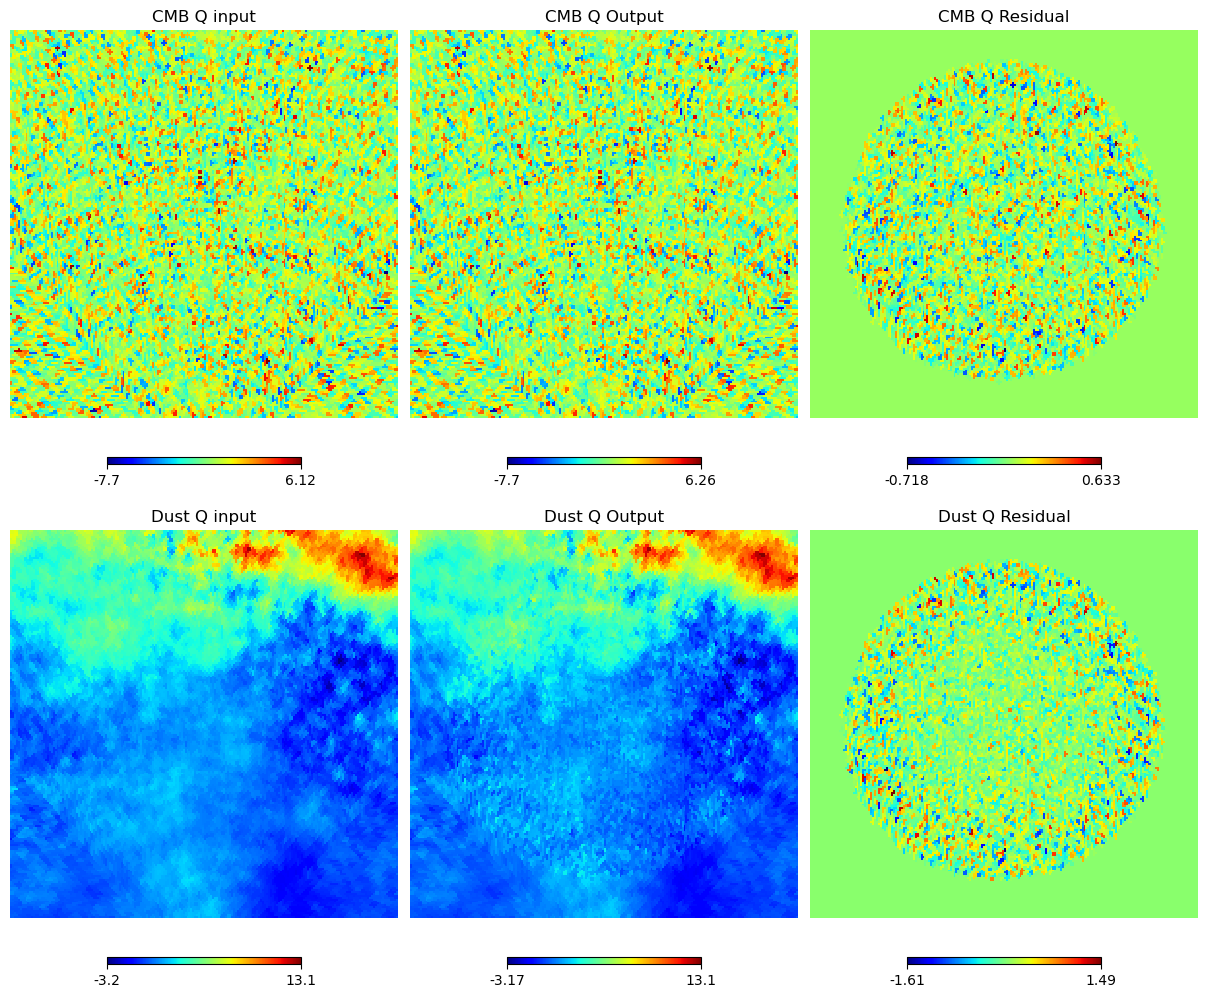

In [8]:
plt.figure(figsize=(12, 10))

# comp_maps_input[:, ~seenpix, :] = hp.UNSEEN
# comp_maps_rec[:, ~seenpix, :] = hp.UNSEEN
# comp_maps_res[:, ~seenpix, :] = hp.UNSEEN

k = 0
istk = 1

for icomp in range(n):
    hp.gnomview((comp_maps_input[icomp, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} input",  
                        cmap="jet",
    
                        sub=(n, 3, k + 1))
    
    hp.gnomview((comp_maps_rec[icomp, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Output",  
                        cmap="jet",
         
                        sub=(n, 3, k + 2))
    
    hp.gnomview(comp_maps_res[icomp, :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Residual",
                        cmap="jet",
                   
        # if self.preset_tools.params["PCG"]["fix_pixels_outside_patch"]:
        #     maps_external[:, ~self.preset_sky.seenpix_qubic, :] = 0
        #     self.TOD_external = _r.T(maps_external)

        #     self.seenpix_external = np.tile(self.preset_sky.seenpix_qubic, (maps_external.shape[0], 3, 1)).reshape(maps_external.shape)
                        sub=(n, 3, k + 3))
    k += 3

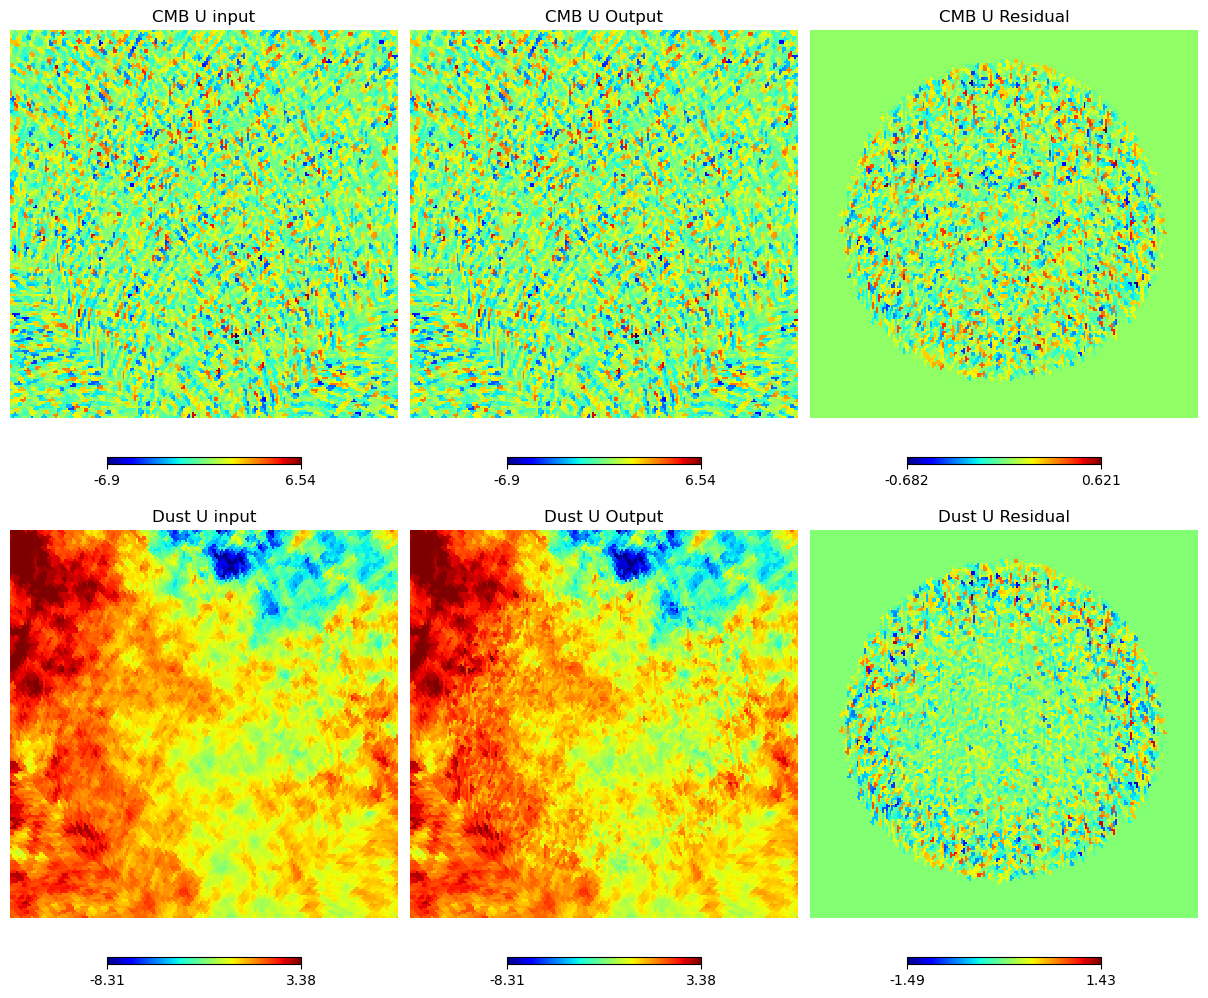

In [9]:
plt.figure(figsize=(12, 10))

min = np.min(comp_maps_input[:, seenpix], axis=1)
max = np.max(comp_maps_input[:, seenpix], axis=1)

k = 0
istk = 2

for icomp in range(n):
    hp.gnomview((comp_maps_input[icomp, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} input",  
                        cmap="jet",
                        min=min[icomp, istk],
                        max=max[icomp, istk],
                        sub=(n, 3, k + 1))
    
    hp.gnomview((comp_maps_rec[icomp, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Output",  
                        cmap="jet",
        # if self.preset_tools.params["PCG"]["fix_pixels_outside_patch"]:
        #     maps_external[:, ~self.preset_sky.seenpix_qubic, :] = 0
        #     self.TOD_external = _r.T(maps_external)

        #     self.seenpix_external = np.tile(self.preset_sky.seenpix_qubic, (maps_external.shape[0], 3, 1)).reshape(maps_external.shape)
                        min=min[icomp, istk],
                        max=max[icomp, istk],
                        sub=(n, 3, k + 2))
    
    hp.gnomview(comp_maps_res[icomp, :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Residual",
                        cmap="jet",
                        # min=min[icomp, istk],
                        # max=max[icomp, istk],
                        sub=(n, 3, k + 3))
    k += 3

(79,) (79,) (79,)


(array([ 0.375,  0.625,  0.875,  1.125,  1.375,  1.625,  1.875,  2.125,
         2.375,  2.625,  2.875,  3.125,  3.375,  3.625,  3.875,  4.125,
         4.375,  4.625,  4.875,  5.125,  5.375,  5.625,  5.875,  6.125,
         6.375,  6.625,  6.875,  7.125,  7.375,  7.625,  7.875,  8.125,
         8.375,  8.625,  8.875,  9.125,  9.375,  9.625,  9.875, 10.125,
        10.375, 10.625, 10.875, 11.125, 11.375, 11.625, 11.875, 12.125,
        12.375, 12.625, 12.875, 13.125, 13.375, 13.625, 13.875, 14.125,
        14.375, 14.625, 14.875, 15.125, 15.375, 15.625, 15.875, 16.125,
        16.375, 16.625, 16.875, 17.125, 17.375, 17.625, 17.875, 18.125,
        18.375, 18.625, 18.875, 19.125, 19.375, 19.625, 19.875]),
 array([0.17841269, 0.11333187, 0.17611996, 0.14339409, 0.14429035,
        0.12941093, 0.16671881, 0.16646638, 0.13407029, 0.13686153,
        0.16279237, 0.15996276, 0.18357221, 0.15108716, 0.14143889,
        0.14921666, 0.15493516, 0.18696699, 0.14210298, 0.15355645,
        0.1550

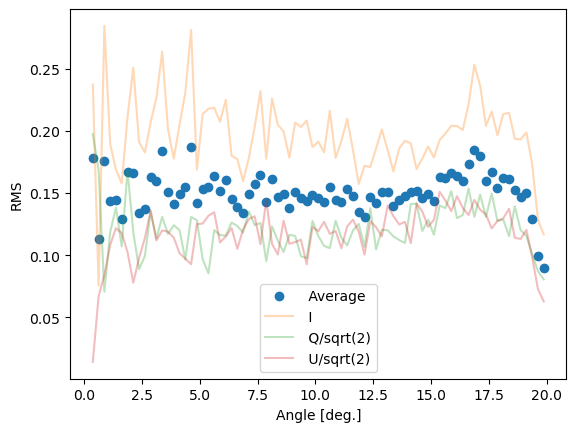

In [10]:
get_angular_profile(comp_maps_res[0], doplot=True, allstokes=True, nbins=80, thmax=20)

# Plot Library

In [11]:
# Map utilities

def build_healpix_map(nside, pix, vals):
    m = np.full(hp.nside2npix(nside), hp.UNSEEN, dtype=float)
    m[pix] = vals
    return m


def pixel_angles(nside, pix):
    theta, phi = hp.pix2ang(nside, pix)
    lon = np.degrees(phi)
    lat = 90.0 - np.degrees(theta)
    return lon, lat


def pixel_labels(vals, precision=2):
    return np.array([f"{v:.{precision}f}" for v in vals])

# healpy wrappers

def plot_mollview_map(m, vals, title="Map"):
    hp.mollview(
        m,
        title=title,
        min=np.min(vals),
        max=np.max(vals),
        hold=True
    )


def plot_gnomview_map(m, vals, center, title="Map", reso=20):
    hp.gnomview(
        m,
        title=title,
        min=np.min(vals),
        max=np.max(vals),
        rot=center,
        reso=reso,
        notext=True,
        hold=True
    )

# Plotting utilities

def annotate_pixels(lon, lat, labels, fontsize=6, weight="bold", color="k"):

    for l, b, label in zip(lon, lat, labels):
        hp.projtext(
            float(l), float(b), str(label),
            lonlat=True,
            fontsize=fontsize,
            fontweight=weight,
            ha="center",
            va="center",
            color=color
        )


def plot_healpix_contour(nside, pix_list, step=4,
                         linewidth=0.8,
                         color="black",
                         label=None,
                         add_legend=True):

    pix_list = np.unique(np.asarray(pix_list))

    contour_handle = None

    for p in pix_list:
        boundary = hp.boundaries(nside, int(p), step=step)
        boundary = np.concatenate([boundary, boundary[:, :1]], axis=1)

        theta, phi = hp.vec2ang(boundary.T)

        lon = np.degrees(phi)
        lat = 90.0 - np.degrees(theta)

        handle = hp.projplot(
            lon,
            lat,
            lonlat=True,
            color=color,
            linewidth=linewidth
        )

        if contour_handle is None and handle:
            contour_handle = handle[0]

    if add_legend and label is not None and contour_handle is not None:
        patch = mpatches.Patch(color=color, label=label)
        plt.legend(handles=[patch])

# Plot beta

In [12]:
nside = hp.npix2nside(data["beta"][-1].size)

pix = data["seenpix_beta"]
vals = (data["beta"][-1, 0] - data["beta_true"][0])[pix]

m = build_healpix_map(nside, pix, vals)
lon, lat = pixel_angles(nside, pix)
labels = pixel_labels(vals)

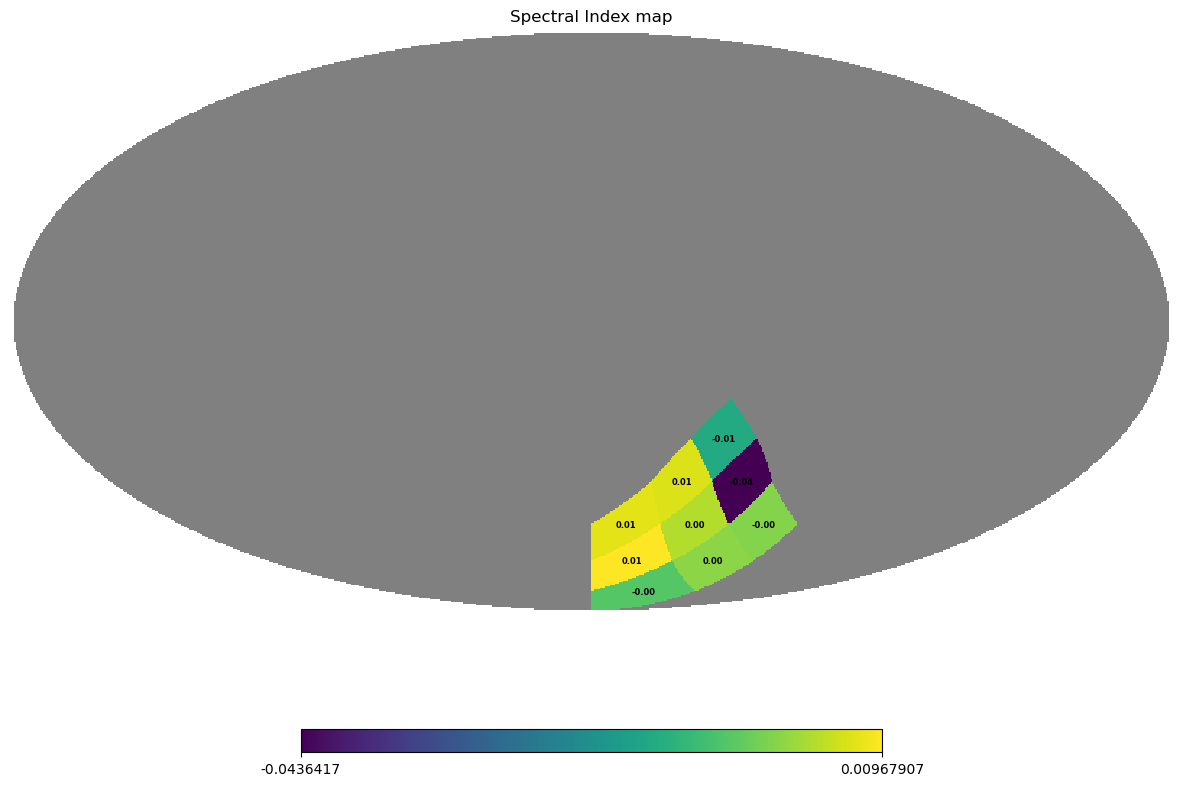

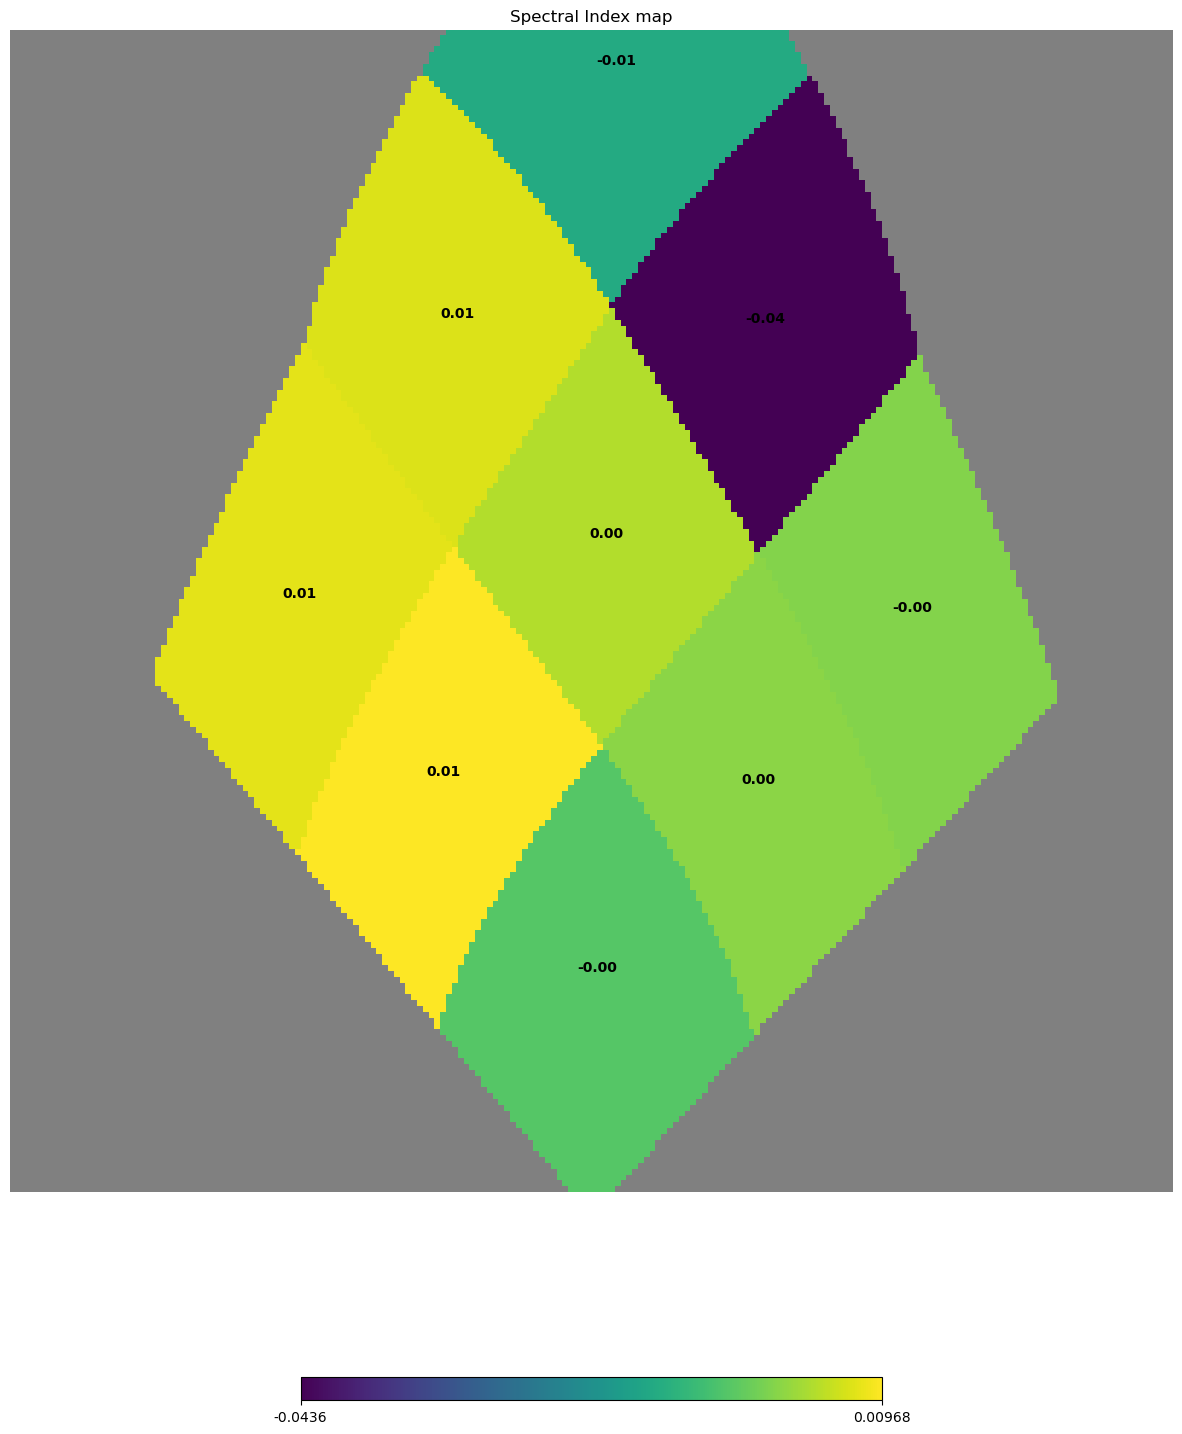

In [13]:
# Mollview beta map

plt.figure(figsize=(15, 30))
plot_mollview_map(m, vals, title="Spectral Index map")
annotate_pixels(lon, lat, labels)

plt.show()

# Gnomview beta map

plt.figure(figsize=(15, 30))
plot_gnomview_map(m, vals, center, title="Spectral Index map")
annotate_pixels(lon, lat, labels, fontsize=10)

plt.show()

<Figure size 640x480 with 0 Axes>

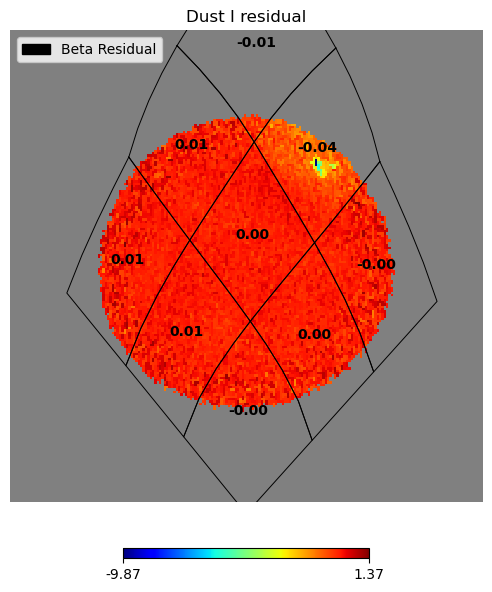

In [14]:
# Print beta over residual maps
plt.figure()

icomp, istk = 1, 0

res = comp_maps_res[icomp, :, istk].copy()
max = np.max([np.abs(np.min(res[seenpix])), np.max(res[seenpix])])
res[~seenpix] = hp.UNSEEN
hp.gnomview(res, rot=center,
                        reso=20,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} residual",  
                        cmap="jet",
                        # min = -max,
                        # max=max
)

annotate_pixels(lon, lat, labels, fontsize=10)
plot_healpix_contour(nside, pix, step=4, linewidth=0.7, label="Beta Residual")
plt.show()